In [2]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.stats import ks_2samp, wasserstein_distance

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
from google.colab import files
uploaded = files.upload()

Saving california_housing.csv to california_housing.csv


In [6]:
df = pd.read_csv("california_housing.csv")

In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.shape

(20640, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


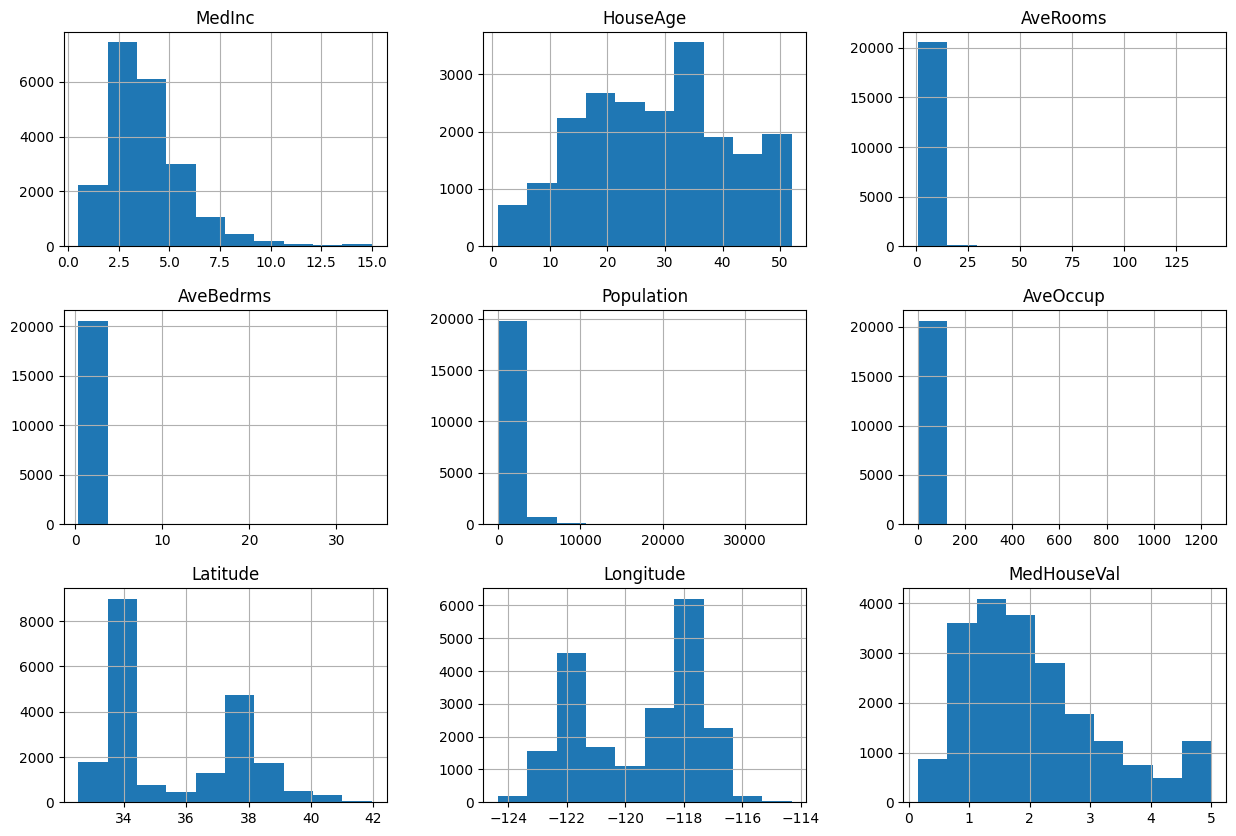

In [11]:
df.hist(figsize=(15,10))
plt.show()

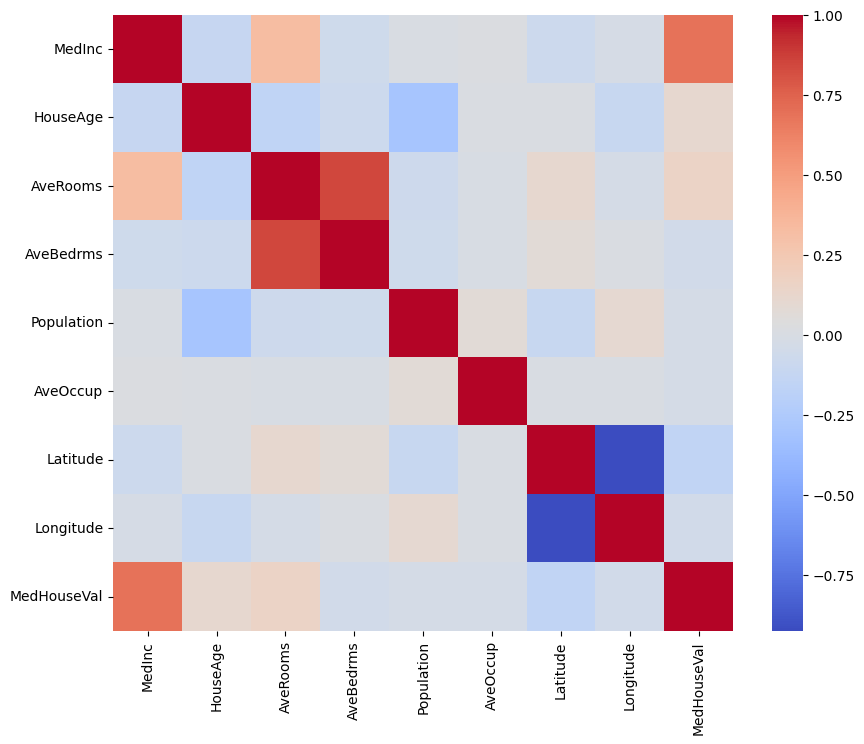

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

Preprocessing

In [13]:
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42)

df_val, df_test = train_test_split( df_temp, test_size=0.5, random_state=42)

In [14]:
df_train.skew().sort_values(ascending=False)

,0
AveOccup,88.052663
AveBedrms,23.170746
AveRooms,18.607090
Population,5.276131
MedInc,1.634090
MedHouseVal,0.976531
Latitude,0.461504
HouseAge,0.063453
Longitude,-0.288418


In [15]:
skewed_features = ['AveOccup','AveBedrms','AveRooms','Population']

for col in skewed_features:
    df_train[col] = np.log1p(df_train[col])
    df_val[col]   = np.log1p(df_val[col])
    df_test[col]  = np.log1p(df_test[col])

In [16]:
df_train[skewed_features].skew()

,0
AveOccup,4.264825
AveBedrms,8.662134
AveRooms,1.338340
Population,-1.034675


In [17]:
scaler = StandardScaler()

df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train), columns=df_train.columns)
df_val_scaled = pd.DataFrame(scaler.transform(df_val), columns=df_val.columns)
df_test_scaled = pd.DataFrame(scaler.transform(df_test), columns=df_test.columns)

In [18]:
scaled_df = pd.DataFrame(df_train_scaled, columns=df_train.columns)
real_corr = scaled_df.corr()

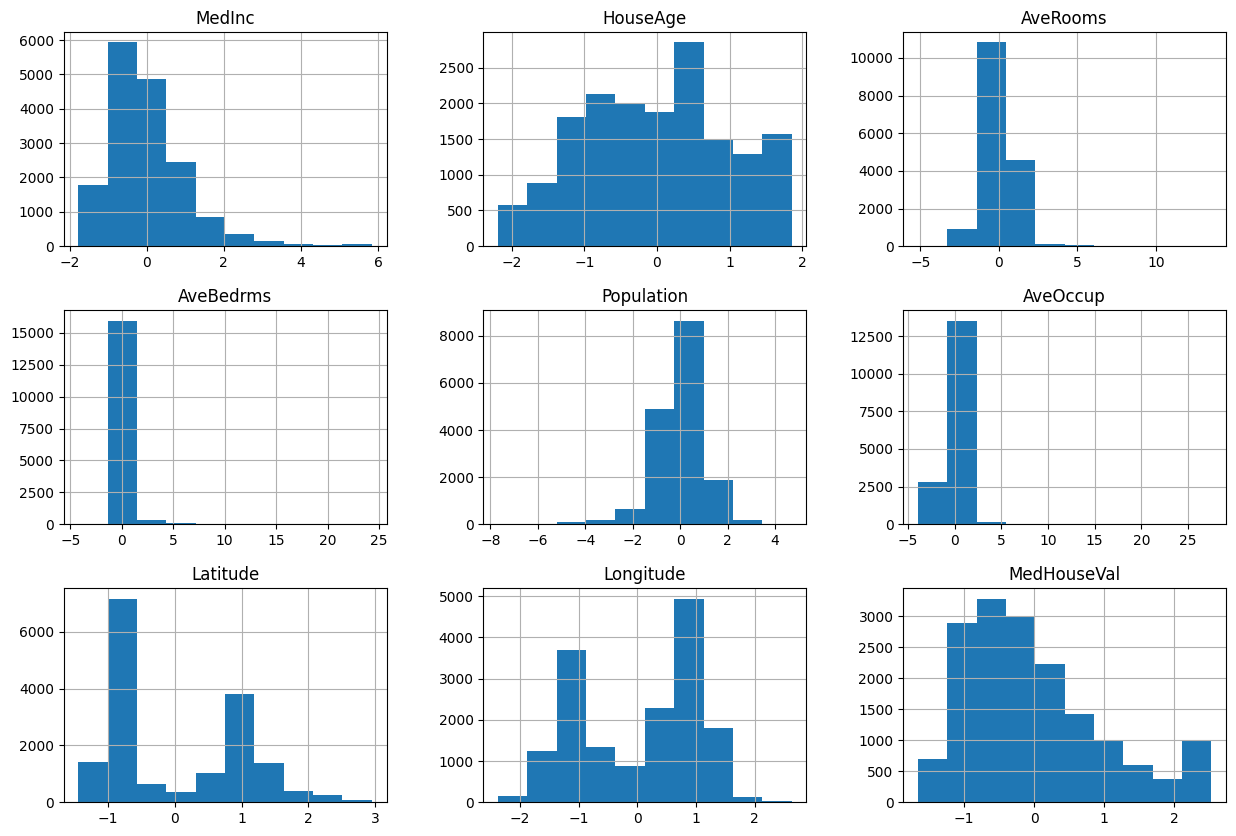

In [19]:
scaled_df.hist(figsize=(15,10))
plt.show()

Dataloader

In [20]:
train_tensor = torch.tensor(df_train_scaled.values, dtype=torch.float32)
val_tensor = torch.tensor(df_val_scaled.values, dtype=torch.float32)
test_tensor = torch.tensor(df_test_scaled.values, dtype=torch.float32)

In [21]:
train_loader = DataLoader(train_tensor, batch_size=128, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size=128, shuffle=False)
test_loader = DataLoader(test_tensor, batch_size=128, shuffle=False)

VAE

In [22]:
class VAE(nn.Module):

    def __init__(
        self,
        input_dim=9,
        hidden_dim1=64,
        hidden_dim2=32,
        latent_dim=4
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(
            hidden_dim2,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            hidden_dim2,
            latent_dim
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim)
        )

    def reparameterize(
        self,
        mu,
        logvar
    ):
        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    def forward(self, x):

        h = self.encoder(x)

        mu = self.fc_mu(h)

        logvar = self.fc_logvar(h)

        z = self.reparameterize(
            mu,
            logvar
        )

        x_recon = self.decoder(z)

        return x_recon, mu, logvar

In [23]:
model = VAE()
x = torch.randn(5, 9)
recon, mu, logvar = model(x)

Loss Function

In [24]:
def vae_loss(recon_x, x, mu, logvar, beta):

    # Reconstruction Loss
    recon_loss = F.mse_loss(recon_x, x, reduction='none')
    recon_loss = recon_loss.sum(dim=1).mean()

    # KL Divergence
    kl_loss = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [25]:
# def get_beta(epoch, max_beta=0.3, warmup=100):

#     beta = min(
#         max_beta,
#         (epoch + 1) / warmup * max_beta
#     )

#     return beta

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

Training

In [27]:
epochs = 300

history = {
    "train_loss": [],
    "val_loss": [],
    "recon_loss": [],
    "val_recon_loss": [],
    "kl_loss": [],
    "val_kl_loss": [],
    "beta": [],
    "beta_kl": []
}

for epoch in range(epochs):

    # Training
    model.train()

    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0

    beta = 0.15

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(batch)

        loss, recon_loss, kl_loss = vae_loss(
            recon,
            batch,
            mu,
            logvar,
            beta
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_loss.item()

    avg_train_loss = running_loss / len(train_loader)
    avg_recon_loss = running_recon / len(train_loader)
    avg_kl_loss = running_kl / len(train_loader)

    # Validation
    model.eval()

    running_val_loss = 0.0
    running_val_recon = 0.0
    running_val_kl = 0.0

    with torch.no_grad():

        for batch in val_loader:

            batch = batch.to(device)

            recon, mu, logvar = model(batch)

            val_loss, val_recon, val_kl = vae_loss(
                recon,
                batch,
                mu,
                logvar,
                beta
            )

            running_val_loss += val_loss.item()
            running_val_recon += val_recon.item()
            running_val_kl += val_kl.item()

    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_recon = running_val_recon / len(val_loader)
    avg_val_kl = running_val_kl / len(val_loader)

    # Store History
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    history["recon_loss"].append(avg_recon_loss)
    history["val_recon_loss"].append(avg_val_recon)

    history["kl_loss"].append(avg_kl_loss)
    history["val_kl_loss"].append(avg_val_kl)

    history["beta"].append(beta)
    history["beta_kl"].append(beta * avg_kl_loss)

    # Save Checkpoint Every 20 Epochs
    if (epoch + 1) % 20 == 0:

        checkpoint_path = f"vae_epoch_{epoch+1}.pth"

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),

                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,

                "recon_loss": avg_recon_loss,
                "val_recon_loss": avg_val_recon,

                "kl_loss": avg_kl_loss,
                "val_kl_loss": avg_val_kl,

                "beta": beta
            },
            checkpoint_path
        )

        print(f"\nCheckpoint saved: {checkpoint_path}")

    # Progress
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Recon: {avg_recon_loss:.4f} | "
        f"Val Recon: {avg_val_recon:.4f} | "
        f"KL: {avg_kl_loss:.4f} | "
        f"Val KL: {avg_val_kl:.4f} | "
        f"Beta: {beta:.4f}"
    )

# Save Final Model
torch.save(model.state_dict(), "vae_final.pth")

print("\nTraining completed.")
print("Final model saved as: vae_final.pth")

Epoch [1/300] | Train Loss: 8.4521 | Val Loss: 6.6664 | Recon: 8.3493 | Val Recon: 6.1625 | KL: 0.6856 | Val KL: 3.3590 | Beta: 0.1500
Epoch [2/300] | Train Loss: 4.8865 | Val Loss: 4.2449 | Recon: 4.1425 | Val Recon: 3.4162 | KL: 4.9597 | Val KL: 5.5252 | Beta: 0.1500
Epoch [3/300] | Train Loss: 3.6966 | Val Loss: 3.1320 | Recon: 2.8343 | Val Recon: 2.1475 | KL: 5.7488 | Val KL: 6.5632 | Beta: 0.1500
Epoch [4/300] | Train Loss: 2.9084 | Val Loss: 2.8430 | Recon: 1.9499 | Val Recon: 1.8718 | KL: 6.3900 | Val KL: 6.4751 | Beta: 0.1500
Epoch [5/300] | Train Loss: 2.6916 | Val Loss: 2.7192 | Recon: 1.7288 | Val Recon: 1.7448 | KL: 6.4188 | Val KL: 6.4958 | Beta: 0.1500
Epoch [6/300] | Train Loss: 2.5929 | Val Loss: 2.6370 | Recon: 1.6294 | Val Recon: 1.6593 | KL: 6.4236 | Val KL: 6.5181 | Beta: 0.1500
Epoch [7/300] | Train Loss: 2.5355 | Val Loss: 2.5789 | Recon: 1.5723 | Val Recon: 1.6001 | KL: 6.4210 | Val KL: 6.5254 | Beta: 0.1500
Epoch [8/300] | Train Loss: 2.4912 | Val Loss: 2.5555 |

In [28]:
def evaluate_checkpoint(checkpoint_path):

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    # Generate synthetic data
    n_samples = len(test_loader.dataset)

    with torch.no_grad():

        z = torch.randn(
            n_samples,
            4,
            device=device
        )

        synthetic_scaled = model.decoder(z)

        synthetic_scaled = (
            synthetic_scaled
            .cpu()
            .numpy()
        )

    # Reverse scaling
    synthetic_data = scaler.inverse_transform(
        synthetic_scaled
    )

    synthetic_df = pd.DataFrame(
        synthetic_data,
        columns=df_test.columns
    )

    # KS Statistic
    ks_scores = []

    for col in df_test.columns:

        ks_stat, _ = ks_2samp(
            df_test[col],
            synthetic_df[col]
        )

        ks_scores.append(ks_stat)

    avg_ks = np.mean(ks_scores)

    # Wasserstein Distance
    wd_scores = []

    for col in df_test.columns:

        wd = wasserstein_distance(
            df_test[col],
            synthetic_df[col]
        )

        wd_scores.append(wd)

    avg_wd = np.mean(wd_scores)

    # Correlation Difference
    real_corr = df_test.corr()

    synthetic_corr = synthetic_df.corr()

    corr_diff = (
        np.abs(real_corr - synthetic_corr)
        .mean()
        .mean()
    )

    return {
        "KS": avg_ks,
        "WD": avg_wd,
        "CorrDiff": corr_diff
    }

In [29]:
results = []

for epoch in range(20, 301, 20):

    checkpoint_path = f"vae_epoch_{epoch}.pth"

    metrics = evaluate_checkpoint(
        checkpoint_path
    )

    metrics["Epoch"] = epoch

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df

,KS,WD,CorrDiff,Epoch
0,0.115579,0.413045,0.068046,20
1,0.093292,0.296081,0.057595,40
2,0.095984,0.355151,0.055736,60
3,0.091031,0.356642,0.055111,80
4,0.086348,0.394025,0.054065,100
5,0.089739,0.378384,0.048517,120
6,0.093669,0.400487,0.061551,140
7,0.086725,0.350825,0.055541,160
8,0.090439,0.377342,0.053796,180
9,0.090278,0.347913,0.048400,200


In [30]:
rank_df = results_df.copy()

rank_df["KS_rank"] = rank_df["KS"].rank()
rank_df["WD_rank"] = rank_df["WD"].rank()
rank_df["Corr_rank"] = rank_df["CorrDiff"].rank()

rank_df["Total_rank"] = (
    rank_df["KS_rank"]
    + rank_df["WD_rank"]
    + rank_df["Corr_rank"]
)

rank_df.sort_values("Total_rank")

,KS,WD,CorrDiff,Epoch,KS_rank,WD_rank,Corr_rank,Total_rank
11,0.081072,0.266551,0.043508,240,2.0,1.0,1.0,4.0
14,0.084894,0.328512,0.050952,300,4.0,4.0,4.0,12.0
12,0.078973,0.323822,0.055550,260,1.0,3.0,11.0,15.0
13,0.082687,0.343797,0.054662,280,3.0,5.0,8.0,16.0
9,0.090278,0.347913,0.048400,200,9.0,6.0,2.0,17.0
5,0.089739,0.378384,0.048517,120,8.0,11.0,3.0,22.0
7,0.086725,0.350825,0.055541,160,6.0,7.0,10.0,23.0
4,0.086348,0.394025,0.054065,100,5.0,12.0,7.0,24.0
10,0.087209,0.410887,0.051682,220,7.0,14.0,5.0,26.0
8,0.090439,0.377342,0.053796,180,10.0,10.0,6.0,26.0


In [31]:
best_epoch = rank_df.sort_values(
    "Total_rank"
).iloc[0]["Epoch"]

print(f"Best checkpoint: Epoch {best_epoch}")

Best checkpoint: Epoch 240.0


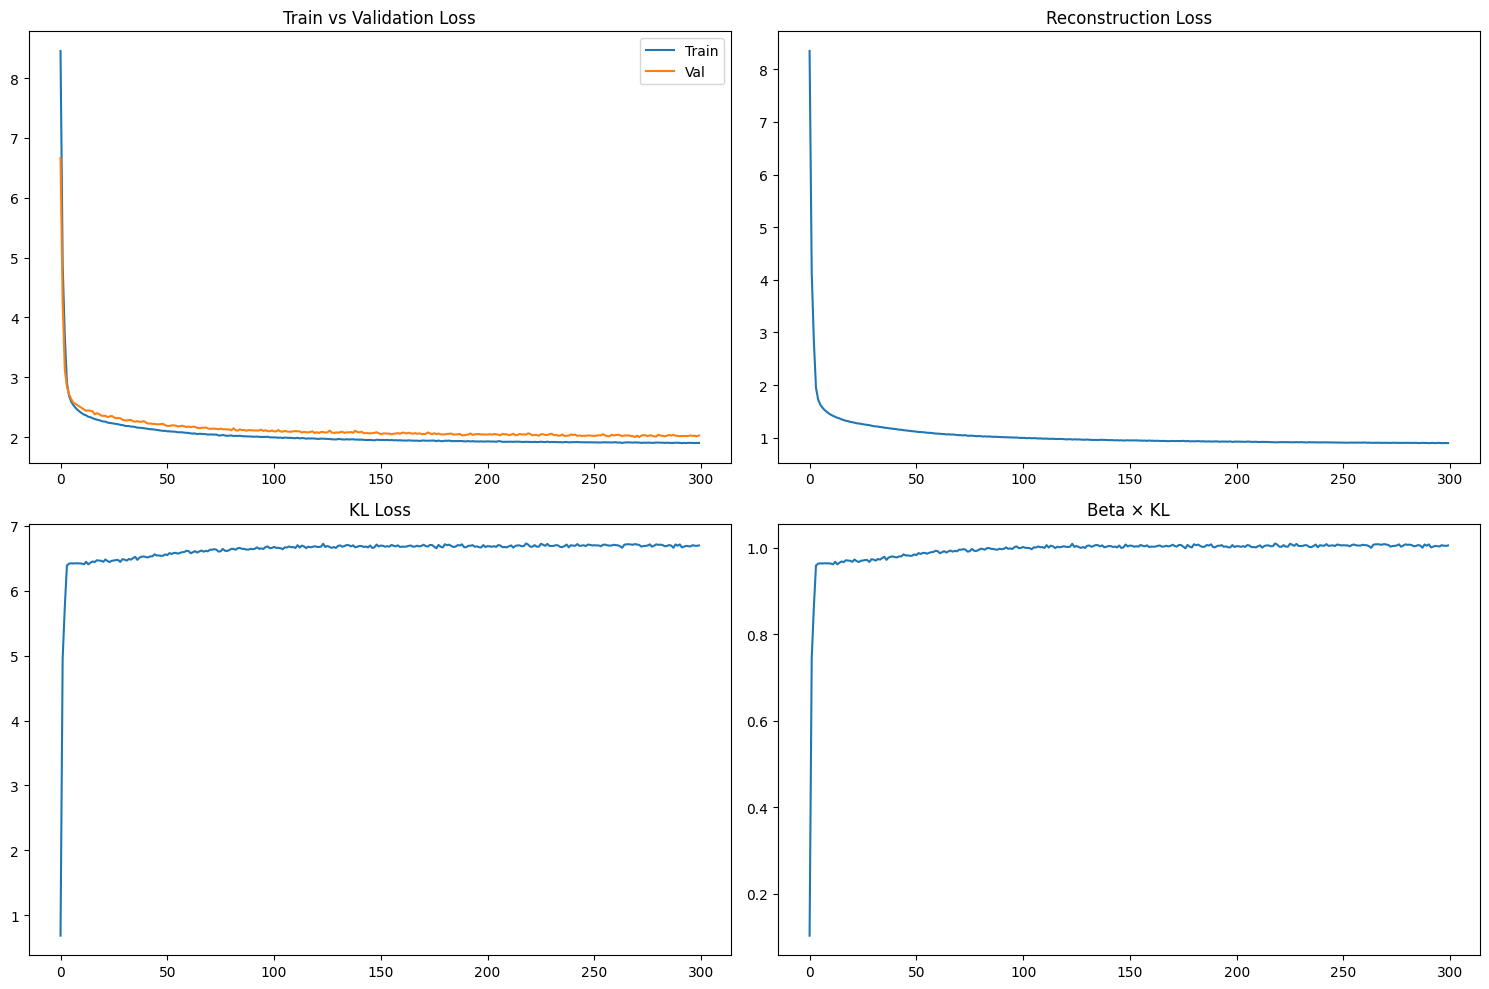

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

axes[0,0].plot(history["train_loss"])
axes[0,0].plot(history["val_loss"])
axes[0,0].set_title("Train vs Validation Loss")
axes[0,0].legend(["Train","Val"])

axes[0,1].plot(history["recon_loss"])
axes[0,1].set_title("Reconstruction Loss")

axes[1,0].plot(history["kl_loss"])
axes[1,0].set_title("KL Loss")

axes[1,1].plot(history["beta_kl"])
axes[1,1].set_title("Beta × KL")

plt.tight_layout()
plt.show()

Synthetic data

In [33]:
model.eval()

n_samples = 500
latent_dim = 4

with torch.no_grad():

    z = torch.randn(
        n_samples,
        latent_dim,
        device=device
    )

    synthetic_scaled = model.decoder(z)

    synthetic_scaled = synthetic_scaled.cpu().numpy()

In [34]:
synthetic_data = scaler.inverse_transform(synthetic_scaled)

In [35]:
synthetic_df = pd.DataFrame(
    synthetic_data,
    columns=[
        'MedInc',
        'HouseAge',
        'AveRooms',
        'AveBedrms',
        'Population',
        'AveOccup',
        'Latitude',
        'Longitude',
        'MedHouseVal'
    ]
)

In [36]:
synthetic_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,3.814927,26.852875,1.809535,0.728521,7.003341,1.339858,35.463608,-119.452393,2.035100
std,1.734609,11.577893,0.189411,0.046679,0.721256,0.190049,1.937475,1.933267,1.099406
min,1.343679,3.905229,1.080534,0.623250,4.233161,0.956759,33.355286,-124.316277,0.530340
25%,2.482471,17.431529,1.696473,0.710249,6.595558,1.216442,33.776958,-121.619608,1.174958
50%,3.439218,26.150447,1.820179,0.721105,7.014782,1.316407,34.114618,-118.370407,1.703257
75%,4.702785,35.123442,1.931943,0.733125,7.459081,1.433941,37.525886,-117.908199,2.610847
max,15.944143,65.177757,2.323032,1.087579,9.217107,2.151989,41.696934,-116.538101,5.344124


In [37]:
df_test.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000
mean,3.833116,28.874031,1.824501,0.730751,7.019663,1.350026,35.558130,-119.509806,2.073502
std,1.862888,12.642963,0.233709,0.112116,0.756460,0.198546,2.114585,2.011528,1.141928
min,0.499900,2.000000,0.613104,0.405465,2.197225,0.840964,32.540000,-124.170000,0.175000
25%,2.548425,18.000000,1.685942,0.695424,6.663133,1.230872,33.930000,-121.810000,1.217500
50%,3.512800,29.000000,1.824362,0.716329,7.055312,1.337370,34.220000,-118.450000,1.781000
75%,4.636825,37.000000,1.951906,0.739412,7.456742,1.454184,37.682500,-117.980000,2.689250
max,15.000100,52.000000,4.894351,3.557251,9.427707,4.432856,41.810000,-114.590000,5.000010


In [38]:
for col in synthetic_df.columns:
    print(
        col,
        (synthetic_df[col] < df_test[col].min()).sum(),
        (synthetic_df[col] > df_test[col].max()).sum()
    )

MedInc 0 1
HouseAge 0 8
AveRooms 0 0
AveBedrms 0 0
Population 0 0
AveOccup 0 0
Latitude 0 0
Longitude 1 0
MedHouseVal 0 6


In [39]:
ks_results = []

for col in df_test.columns:

    ks_stat, p_value = ks_2samp(
        df_test[col],
        synthetic_df[col]
    )

    ks_results.append([
        col,
        ks_stat,
        p_value
    ])

ks_df = pd.DataFrame(
    ks_results,
    columns=[
        "Feature",
        "KS Statistic",
        "P Value"
    ]
)

ks_df

,Feature,KS Statistic,P Value
0,MedInc,0.063992,7.036702e-02
1,HouseAge,0.122446,1.014007e-05
2,AveRooms,0.050795,2.404890e-01
3,AveBedrms,0.213833,1.293680e-16
4,Population,0.050353,2.493349e-01
5,AveOccup,0.085438,5.224030e-03
6,Latitude,0.152422,1.247357e-08
7,Longitude,0.063360,7.511613e-02
8,MedHouseVal,0.069287,3.968432e-02


Comparision of old and new data

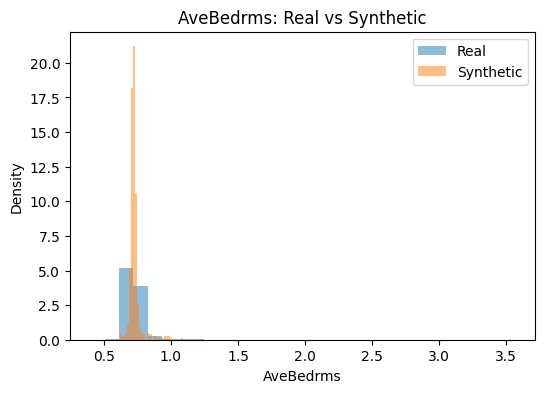

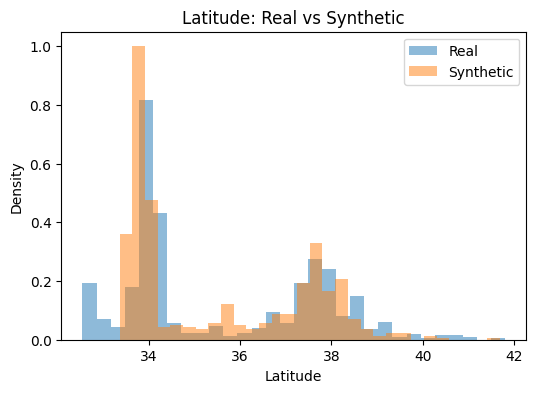

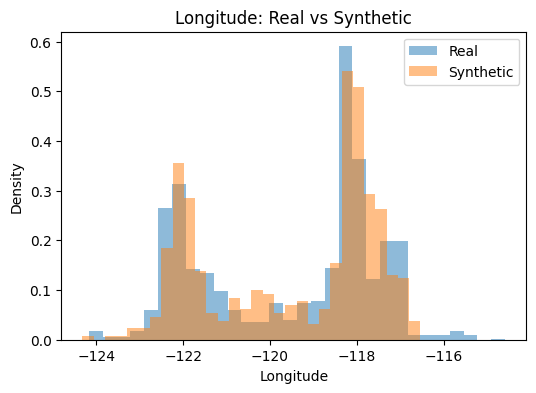

In [40]:
columns_to_plot = [
    "AveBedrms",
    "Latitude",
    "Longitude"
]

for col in columns_to_plot:

    plt.figure(figsize=(6,4))

    plt.hist(
        df_test[col],
        bins=30,
        alpha=0.5,
        density=True,
        label="Real"
    )

    plt.hist(
        synthetic_df[col],
        bins=30,
        alpha=0.5,
        density=True,
        label="Synthetic"
    )

    plt.title(f"{col}: Real vs Synthetic")

    plt.xlabel(col)

    plt.ylabel("Density")

    plt.legend()

    plt.show()

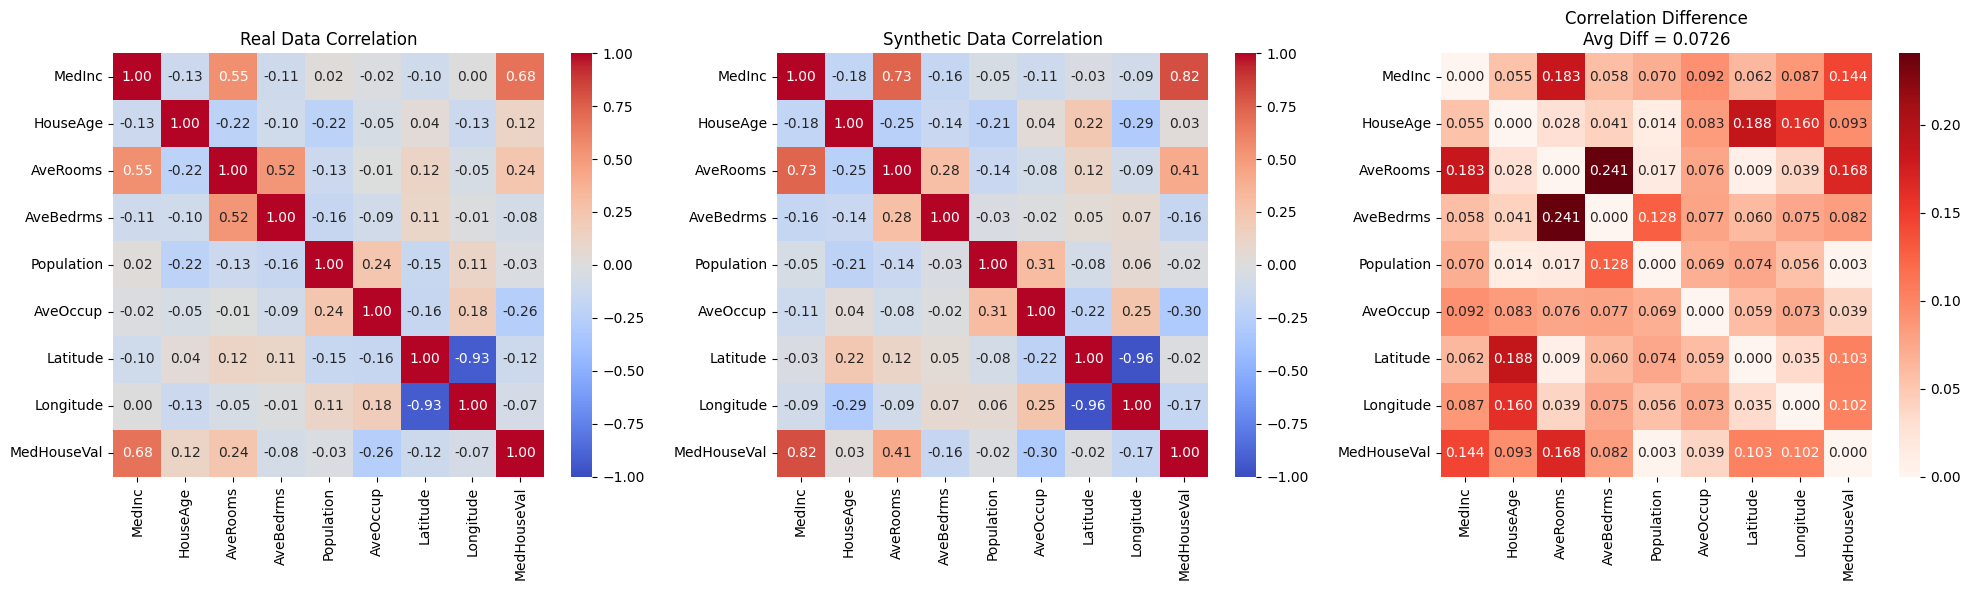

In [41]:
real_corr = df_test.corr()

synthetic_corr = synthetic_df.corr()

corr_diff = abs(
    real_corr - synthetic_corr
)

avg_corr_diff = (
    corr_diff.mean()
    .mean()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20,6)
)

# Real correlation
sns.heatmap(
    real_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    ax=axes[0]
)

axes[0].set_title(
    "Real Data Correlation"
)

# Synthetic correlation
sns.heatmap(
    synthetic_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    ax=axes[1]
)

axes[1].set_title(
    "Synthetic Data Correlation"
)

# Difference matrix
sns.heatmap(
    corr_diff,
    cmap="Reds",
    annot=True,
    fmt=".3f",
    ax=axes[2]
)

axes[2].set_title(
    f"Correlation Difference\nAvg Diff = {avg_corr_diff:.4f}"
)

plt.tight_layout()

plt.show()

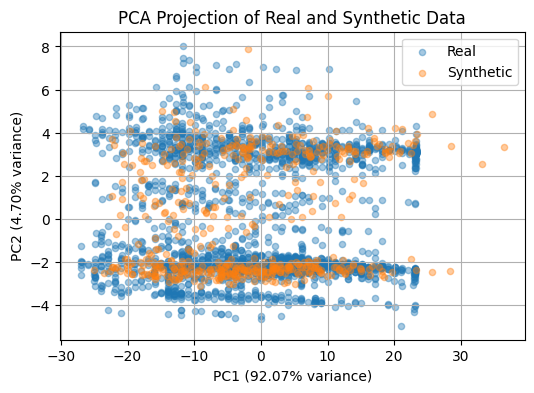

In [42]:
pca = PCA(n_components=2)

real_pca = pca.fit_transform(df_test)

synthetic_pca = pca.transform(synthetic_df)

plt.figure(figsize=(6,4))

plt.scatter(
    real_pca[:,0],
    real_pca[:,1],
    s=20,
    alpha=0.4,
    label="Real"
)

plt.scatter(
    synthetic_pca[:,0],
    synthetic_pca[:,1],
    s=20,
    alpha=0.4,
    label="Synthetic"
)

plt.title("PCA Projection of Real and Synthetic Data")

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.2f}% variance)"
)

plt.legend()

plt.grid(True)

plt.show()

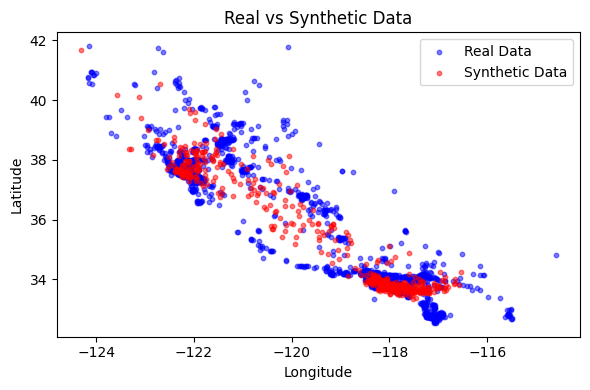

In [43]:
plt.figure(figsize=(6,4))

# Real data
plt.scatter(
    df_test["Longitude"],
    df_test["Latitude"],
    color="blue",
    alpha=0.5,
    s=10,
    label="Real Data"
)

# Synthetic data
plt.scatter(
    synthetic_df["Longitude"],
    synthetic_df["Latitude"],
    color="red",
    alpha=0.5,
    s=10,
    label="Synthetic Data"
)

plt.title("Real vs Synthetic Data")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# Mean vectors
train_means = df_train.mean()

test_means = df_test.mean()

synthetic_means = synthetic_df.mean()

# Put into one table
mean_comparison = pd.DataFrame({
    "Train Mean": train_means,
    "Test Mean": test_means,
    "Synthetic Mean": synthetic_means
})

mean_comparison

,Train Mean,Test Mean,Synthetic Mean
MedInc,3.880754,3.833116,3.814927
HouseAge,28.608285,28.874031,26.852861
AveRooms,1.830073,1.824501,1.809535
AveBedrms,0.732341,0.730751,0.728521
Population,7.026836,7.019663,7.003341
AveOccup,1.351463,1.350026,1.339859
Latitude,35.643149,35.558130,35.463627
Longitude,-119.582290,-119.509806,-119.452438
MedHouseVal,2.071947,2.073502,2.035100


In [45]:
train_syn_mse = np.mean(
    (train_means - synthetic_means) ** 2
)

test_syn_mse = np.mean(
    (test_means - synthetic_means) ** 2
)

train_test_mse = np.mean(
    (train_means - test_means) ** 2
)

print(f"Train vs Synthetic Mean squared difference : {train_syn_mse:.6f}")
print(f"Test vs Synthetic Mean squared difference : {test_syn_mse:.6f}")
print(f"Train vs Test Mean squared difference : {train_test_mse:.6f}")

Train vs Synthetic Mean squared difference : 0.348602
Test vs Synthetic Mean squared difference : 0.455528
Train vs Test Mean squared difference : 0.009496
